# Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the loss function by iteratively updating model parameters toward the best-fit line.  

### Key Properties

- Optimizes the loss/error function
- Finds the best-fit line for the dataset
- Moves step-by-step toward the minimum error point
- Tries to reach the local minima (best optimization point)
- Works iteratively by updating coefficients repeatedly

In [7]:
# Lets make a suitable dataset for this excercise 
from sklearn.datasets import make_regression  
import numpy as np 
import matplotlib.pyplot as plt 

In [86]:
x,y = make_regression(n_samples=4 ,  # no of rows 
                     n_features=1 ,  # np of columns
                     n_informative=1 ,  # no of relevent Cols
                     n_targets= 1 ,   # Output column
                     noise=80,        # Adds randomness/disturbance to make the dataset more realistic
                     random_state=13)

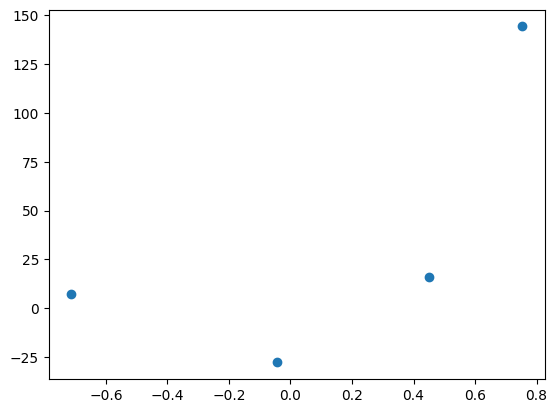

In [4]:
plt.scatter(x,y)

In [5]:
#  Lets see the Original values of m,b using sklearn , after that we will try to acheive same results by coding it from scratch 

In [6]:
# Lets apply OLS 
from sklearn.linear_model import LinearRegression 

In [12]:
reg = LinearRegression()
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# m
reg.coef_

array([78.35063668])

In [14]:
# b.intercept_
reg.intercept_

np.float64(26.15963284313262)

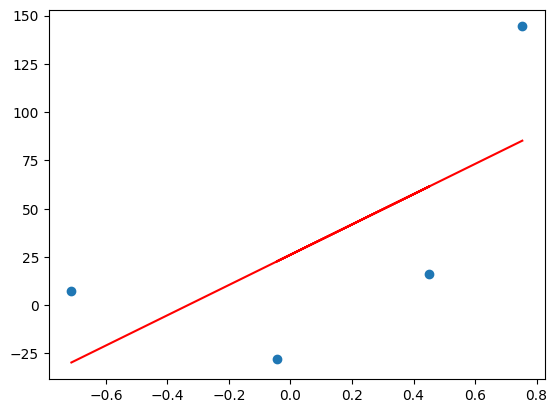

In [16]:
# Best Fit Line  
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color = 'red')

#### Now lets see How Gradient Descent works to find the Best Fit line

In [45]:
# for the , Basic understanding purpose , we'll assumne 'm' constant , and randomising only 'b' in the equation 
# m = 78.35    ( FIXED for this eg)
# b = 100      ( Our 1 assumation is 100)

# prediction Equation :
y_pred = ((78.35 * x) + 100).reshape(4) 

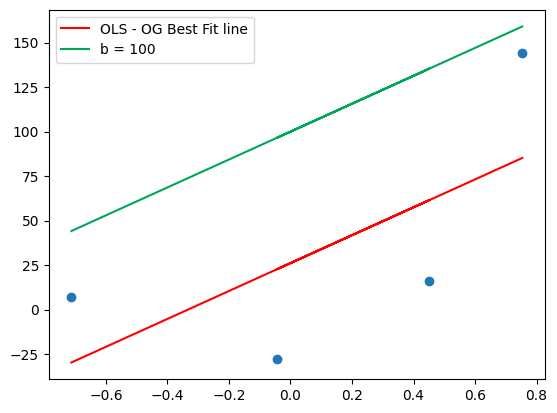

In [46]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS - OG Best Fit line')
plt.plot(x,y_pred,color='#00a65a',label='b = 100')
plt.legend()
plt.show()
     

In [47]:
# Lets Calcu the Loss Function 

m = 78.35   # Fixed 
b = 100 # Assumed intercept value

loss_slope = -2 * np.sum(y - m*x.ravel() - b)              # ravel() = Convert a multi-dimensional array into a flat 1D array.
loss_slope

np.float64(590.7223659179078)

In [48]:
# Lets take Learning rate (step size)

lr = 0.1 

step_size = loss_slope*lr
step_size

np.float64(59.072236591790784)

In [49]:
# calcu the new intercepter 
b_new = b - step_size 

In [50]:
b_new

np.float64(40.927763408209216)

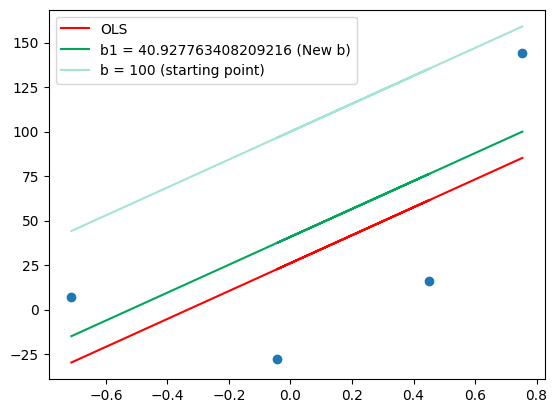

In [76]:
# Now lets see where Our Best fit line lies 
y_pred1 = ((78.35 * x) + b_new).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred1,color='#00a65a',label='b1 = {} (New b)'.format(b_new))
plt.plot(x,y_pred,color='#A3E4D7',label='b = {} (starting point)' .format(b))
plt.legend()
plt.show()

#### Lets repeate this steps till we reach our Original Best Fit Line

In [55]:
# Iteration 2 
loss_slope = -2 * np.sum(y - m*x.ravel() - b_new)
loss_slope

np.float64(118.14447318358157)

In [56]:
step_size = loss_slope*lr
step_size

np.float64(11.814447318358157)

In [57]:
# b_new2
b_new2 = b_new - step_size
b_new2

np.float64(29.11331608985106)

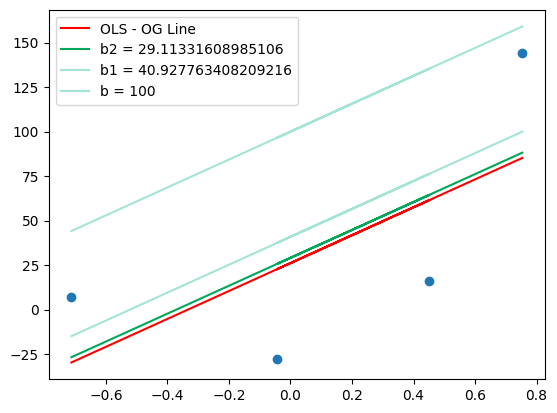

In [75]:
y_pred2 = ((78.35 * x) + b_new2).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS - OG Line')
plt.plot(x,y_pred2,color='#00a65a',label='b2 = {}'.format(b_new2))        # b_new2
plt.plot(x,y_pred1,color='#A3E4D7',label='b1 = {}'.format(b_new))        # b_new
plt.plot(x,y_pred,color='#A3E4D7',label='b = 100')              # 1 estimation 
plt.legend() 
plt.show()

In [66]:
# we are much closer now 

In [68]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*x.ravel() - b_new2)
loss_slope

np.float64(23.62889463671634)

In [69]:
step_size = loss_slope*lr
step_size

np.float64(2.362889463671634)

In [70]:
# b_new3
b_new3 = b_new2 - step_size
b_new3

np.float64(26.750426626179426)

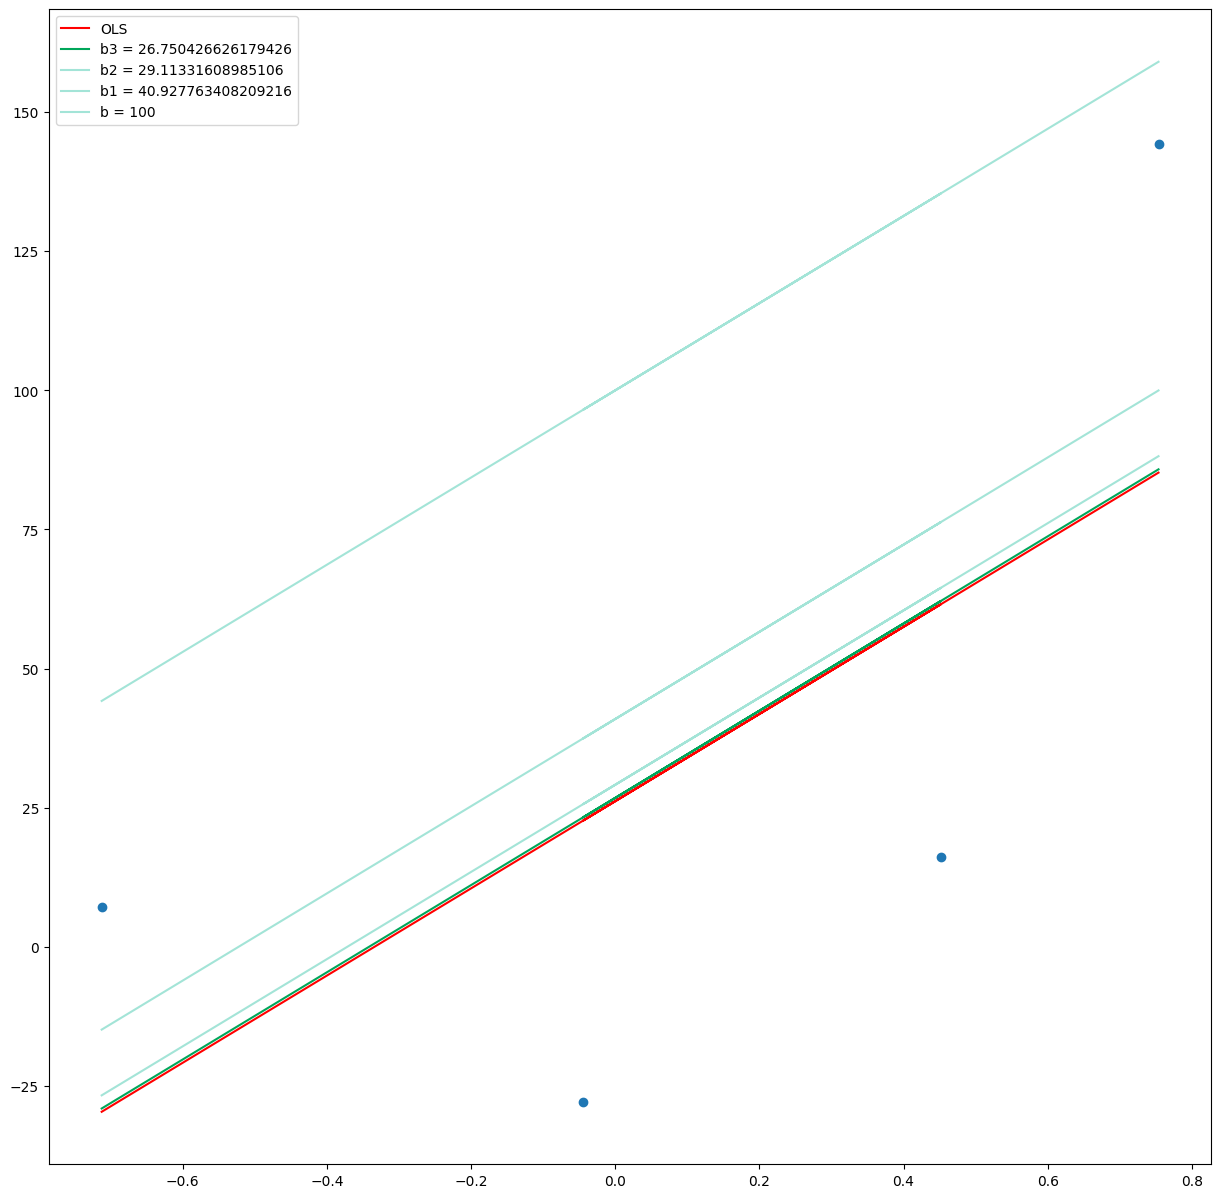

In [74]:
y_pred3 = ((78.35 * x) + b_new3).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred3,color='#00a65a',label='b3 = {}'.format(b_new3))
plt.plot(x,y_pred2,color='#A3E4D7',label='b2 = {}'.format(b_new2))
plt.plot(x,y_pred1,color='#A3E4D7',label='b1 = {}'.format(b_new))
plt.plot(x,y_pred,color='#A3E4D7',label='b = 100')
plt.legend()
plt.show()

### Lets Make a Function for these Steps 

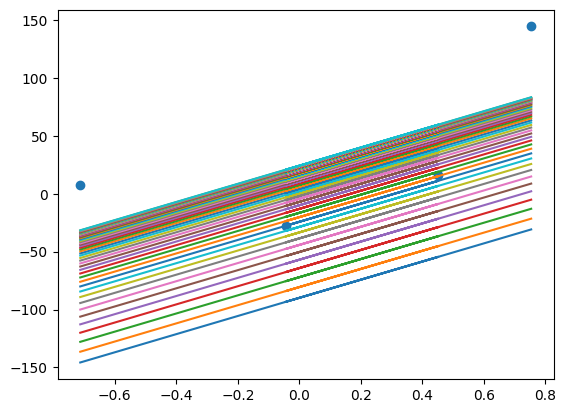

In [85]:
b = -100
m = 78.35
lr = 0.01  #Learning rate 

epochs = 50  # no of time the loop runs 

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*x.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * x + b

  plt.plot(x,y_pred)

plt.scatter(x,y)

### Importance of Learning Rate and Epochs in Gradient Descent

- **Learning Rate (`lr`)** controls the step size during optimization.
  - If the learning rate is too small, the model takes very tiny steps and training becomes very slow.
  - If the learning rate is too high, the model may take huge jumps and overshoot the best-fit line or minima 
  
- **Epochs** represent how many times the algorithm updates the parameters.
  - If epochs are too low, training may stop before reaching the optimal solution.
  - If epochs are too high, it increases unnecessary computational cost.

> Therefore, choosing an optimal learning rate and optimal number of epochs is very important for efficient and accurate training.